## Notebook 04: Household Grocery Expenditure Classification

### Purpose

This notebook examines spatial patterns in estimated annual grocery expenditure per household across census tracts in Kootenai County.

Census tracts are classified into household grocery expenditure groups based on estimated average household grocery spending. Demographic characteristics are summarized and compared across expenditure groups to explore differences in household-level spending patterns.

### Output

A classified spatial dataset and choropleth map showing household grocery expenditure patterns across Kootenai County.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import geopandas as gpd 
import pandas as pd
from adjustText import adjust_text


In [4]:
project_root = Path.cwd()
if not Path('data').exists():
    project_root = project_root.parent
print(project_root)

d:\Wu\2026\Project Portfolio\003 Project\grocery-demand-estimation


### Load spatial data

In [5]:
demand_path = project_root / 'data/processed/potential_grocery_demand.gpkg'
city_path = project_root / 'data/processed/kootenai_cities.gpkg'

In [6]:
demand = gpd.read_file(demand_path, layer='tract_demand')
city = gpd.read_file(city_path, layer='cities')

In [7]:
demand.columns

Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOIDFQ', 'GEOID', 'NAME',
       'NAMELSAD', 'STUSPS', 'NAMELSADCO', 'STATE_NAME', 'LSAD', 'ALAND',
       'AWATER', 'state', 'county', 'tract', 'household_count',
       'avg_household_size', 'median_income', 'median_age', 'owner_rate',
       'college_plus_pct', 'avg_grocery', 'potential_grocery_deman',
       'geometry'],
      dtype='str')

In [8]:
demo_list = ['household_count',
       'avg_household_size', 'median_income', 'median_age', 'owner_rate',
       'college_plus_pct', 'avg_grocery']


### Grocery expenditure analysis at Household level 

In [9]:
demand['avg_grocery'].value_counts()

avg_grocery
5842.281205    25
7120.717148    11
4926.023063     3
Name: count, dtype: int64

In [10]:
demand['avg_grocery'].unique()

array([7120.71714758, 4926.02306334, 5842.28120479])

In [11]:
for v in demand['avg_grocery'].unique():
    print(repr(v))

np.float64(7120.717147583165)
np.float64(4926.023063341427)
np.float64(5842.281204792462)


#### Create Grocery labels

In [12]:
grocery_labels = {
    4926.02: "Low ($4926)",
    5842.28: "Medium ($5842)",
    7120.72: "High ($7120)"
}

demand["grocery_group"] = demand["avg_grocery"].round(2).map(grocery_labels)
demand[["avg_grocery", "grocery_group"]].head()

,avg_grocery,grocery_group
0,7120.717148,High ($7120)
1,4926.023063,Low ($4926)
2,5842.281205,Medium ($5842)
3,5842.281205,Medium ($5842)
4,5842.281205,Medium ($5842)


In [13]:
demand["grocery_group"] = pd.Categorical(
    demand["grocery_group"],
    categories=[
        "Low ($4926)",
        "Medium ($5842)",
        "High ($7120)"
    ],
    ordered=True
)

#### Summarize demographics

In [14]:
grocery_summary = (
    demand
    .groupby("grocery_group")[
        [
            "household_count",
            "avg_household_size",
            "median_income",
            "median_age",
            "owner_rate",
            "college_plus_pct"
        ]
    ]
    .mean()
    .round(2)
)

grocery_summary

,household_count,avg_household_size,median_income,median_age,owner_rate,college_plus_pct
grocery_group,,,,,,
Low ($4926),1621.67,1.81,40838.33,44.33,31.14,21.55
Medium ($5842),1893.68,2.54,79257.36,42.63,72.21,29.45
High ($7120),1724.09,2.58,106513.73,47.48,84.80,35.83


In [15]:
grocery_summary.to_csv(project_root/"outputs/household_demand_profile.csv")

#### Correlation 

In [16]:
corr_df = demand[demo_list]

In [17]:
corr_matrix = corr_df.corr()

grocery_corr = (
    corr_matrix["avg_grocery"]
    .drop("avg_grocery")
    .sort_values(ascending=False)
)

grocery_corr.round(2)

median_income         0.83
owner_rate            0.64
college_plus_pct      0.41
avg_household_size    0.35
median_age            0.23
household_count      -0.04
Name: avg_grocery, dtype: float64

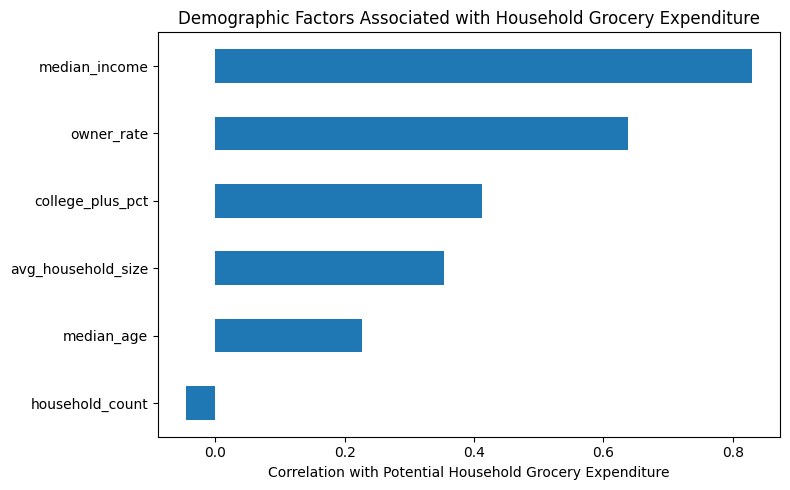

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

grocery_corr.sort_values().plot(
    kind="barh",
    ax=ax
)

ax.set_xlabel("Correlation with Potential Household Grocery Expenditure")
ax.set_title("Demographic Factors Associated with Household Grocery Expenditure")

plt.tight_layout()

fig.savefig(
    project_root / "outputs/household_grocery_expenditure_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Spatial Distribution Pattern of Grocery Demand

In [26]:
demand = demand.to_crs(epsg=26911)
city = city.to_crs(epsg=26911)


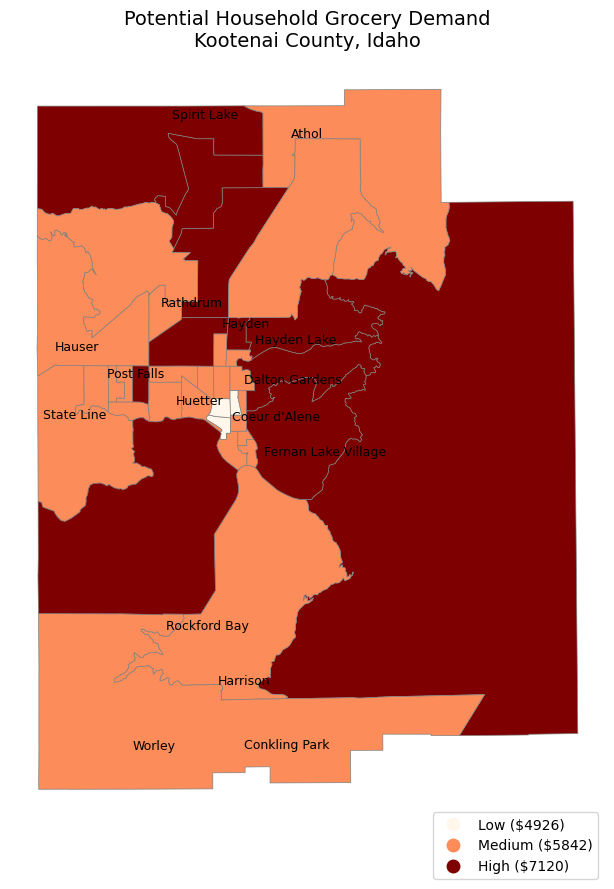

In [28]:
fig, ax = plt.subplots(figsize=(10,10))

demand.plot(
    column='grocery_group',
    cmap="OrRd",
    linewidth=0.5,
    edgecolor="grey",
    legend=True,
    ax=ax
)

texts = []
for _, row in city.iterrows():
    label_point = row.geometry.representative_point()
    texts.append(
        ax.text(
            label_point.x,
            label_point.y,
            row["NAME"],
            color='black',
            fontsize=9
        )
    )

adjust_text(texts)

ax.set_axis_off()
ax.set_title(
    "Potential Household Grocery Demand\nKootenai County, Idaho",
    fontsize=14
    )
legend = ax.get_legend()
legend.set_bbox_to_anchor((1, -0.08))
legend._loc = 4

fig.savefig(
    project_root / "outputs/household_grocery_demand_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()